**Step-1: Import packages**

In [2]:
import pandas as pd
import os

In [3]:
os.listdir(os.getcwd())

['.ipynb_checkpoints',
 'california_app.py',
 'california_app1.py',
 'california_model.joblib',
 'california_model.pkl',
 'Classification_without_hyperparameter_tuning.ipynb',
 'Data Analysis',
 'flask_session',
 'Linear_regression_california.ipynb',
 'mbox-short.txt',
 'Model_load.ipynb',
 'Preprocessed_data.csv',
 'Python sessions',
 'python_oops',
 'Untitled.ipynb',
 'vscode_session']

In [4]:
df=pd.read_csv('Preprocessed_data.csv')

In [5]:
df.shape

(4835, 31)

**Step-2: Divide into X and y**

In [7]:
df.columns

Index(['Gender', 'Age', 'Married', 'Number of Dependents', 'Latitude',
       'Longitude', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Type',
       'Avg Monthly GB Download', 'Online Security', 'Online Backup',
       'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract',
       'Paperless Billing', 'Payment Method', 'Monthly Charge',
       'Total Charges', 'Total Refunds', 'Total Extra Data Charges',
       'Total Long Distance Charges', 'Total Revenue', 'Customer Status'],
      dtype='object')

In [8]:
# It is different telecom churn
# target : Customer Status
X=df.drop('Customer Status',axis=1)
y= df['Customer Status']


In [9]:
df.shape

(4835, 31)

**Step-3: train test split**

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1234)


**Step-4: Model development : DT**

In [13]:
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [14]:
DT=DecisionTreeClassifier()
DT.fit(X_train,y_train)

DecisionTreeClassifier()

In [15]:
y.unique()

array([1, 0], dtype=int64)

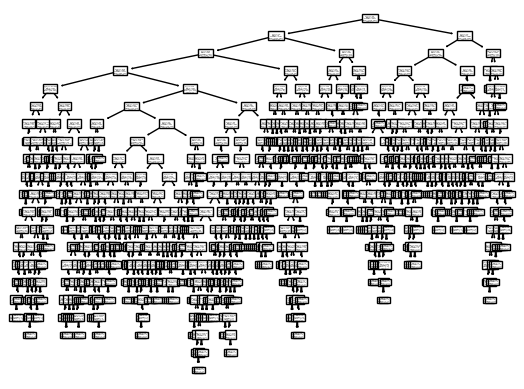

In [16]:
import matplotlib.pyplot as plt
plot_tree(DT,
          class_names=['yes','no']
         )
plt.show()

**Step-5: Model predictions**

In [18]:
y_pred=DT.predict(X_test)

In [19]:
X_test.shape,y_pred.shape

((967, 30), (967,))

In [20]:
prediction_df=X_test.copy()
prediction_df['Y_actual']=y_test
prediction_df['Y_pred']=y_pred
prediction_df

,Gender,Age,Married,Number of Dependents,Latitude,Longitude,Number of Referrals,Tenure in Months,Offer,Avg Monthly Long Distance Charges,...,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Y_actual,Y_pred
173,1,21,0,0,38.067204,-122.524004,0,23,0,38.69,...,1,0,90.60,1943.20,4.73,0,889.87,2828.34,0,1
2856,0,49,1,0,40.936285,-121.572692,1,72,0,38.28,...,0,0,88.05,6520.80,29.11,0,2756.16,9247.85,1,1
4292,1,33,0,0,36.008958,-118.891593,0,28,3,30.48,...,1,0,105.70,2979.50,0.00,80,853.44,3912.94,0,0
1123,0,41,0,0,33.141265,-116.967221,0,62,2,32.58,...,1,0,100.15,6413.65,0.00,0,2019.96,8433.61,0,1
3996,1,47,1,0,34.174493,-117.870680,6,71,0,35.09,...,0,0,83.20,6126.10,0.00,0,2491.39,8617.49,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
839,0,59,1,0,35.634488,-120.293534,4,72,0,6.23,...,0,0,80.45,5737.60,0.00,130,448.56,6316.16,1,1
2349,0,74,0,0,34.108833,-118.229715,0,3,0,46.65,...,0,0,73.85,196.40,0.00,0,139.95,336.35,1,1
643,1,80,1,0,36.125529,-120.864443,0,1,5,39.10,...,1,0,70.30,70.30,0.00,0,39.10,109.40,0,0
1204,1,61,1,0,35.245035,-118.905553,10,35,0,13.39,...,1,0,73.45,2661.10,0.00,0,468.65,3129.75,1,1


**Step-6: Evaluation**

In [22]:
#tp,tn,fp,fn
import numpy as np
tp=np.sum((y_test==1) & (y_pred==1))
tn=np.sum((y_test==0) & (y_pred==0))
fp=np.sum((y_test==0) & (y_pred==1))
fn=np.sum((y_test==1) & (y_pred==0))
tp,tn,fp,fn

(520, 198, 110, 139)

**accuracy-precision-recall-f1**

In [24]:
acc=(tp+tn)/(tp+tn+fp+fn)
pr=tp/(tp+fp)
rc=tp/(tp+fn)
f1=2*pr*rc/(pr+rc)
acc,pr,rc,f1

(0.7425025853154085,
 0.8253968253968254,
 0.7890743550834598,
 0.8068269976726143)

In [25]:
from sklearn.metrics import accuracy_score,precision_score,\
                            recall_score,f1_score, \
                            confusion_matrix,ConfusionMatrixDisplay,\
                            roc_curve,auc

In [26]:
cmt=confusion_matrix(y_test,y_pred)
cmt

array([[198, 110],
       [139, 520]], dtype=int64)

In [27]:
tn,fp,fn,tp=cmt.flatten()

<Axes: >

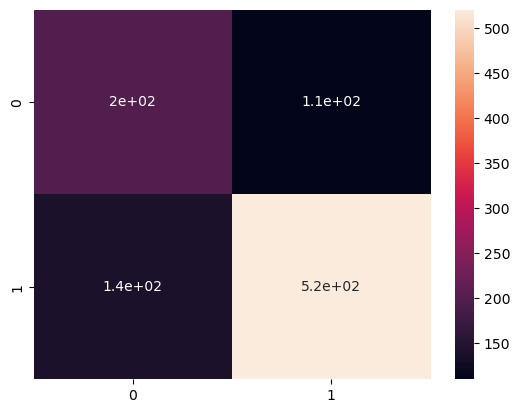

In [28]:
import seaborn as sns
sns.heatmap(cmt,annot=True)

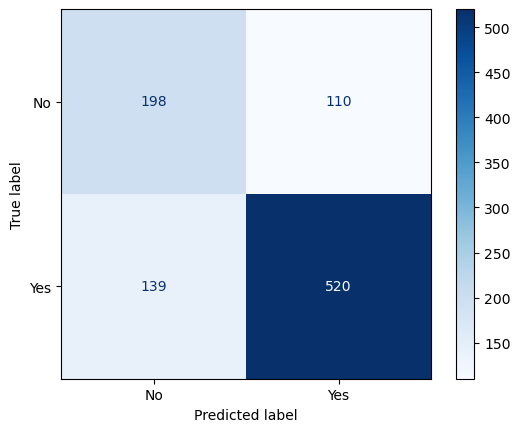

In [29]:
ConfusionMatrixDisplay(cmt,display_labels=['No','Yes']).plot(cmap='Blues')
plt.show()

In [30]:
acc_dt=round(accuracy_score(y_test,y_pred),2)
acc_pr=round(precision_score(y_test,y_pred),2)
acc_rc=round(recall_score(y_test,y_pred),2)
acc_f1=round(f1_score(y_test,y_pred),2)

acc_dt,acc_pr,acc_rc,acc_f1

(0.74, 0.83, 0.79, 0.81)

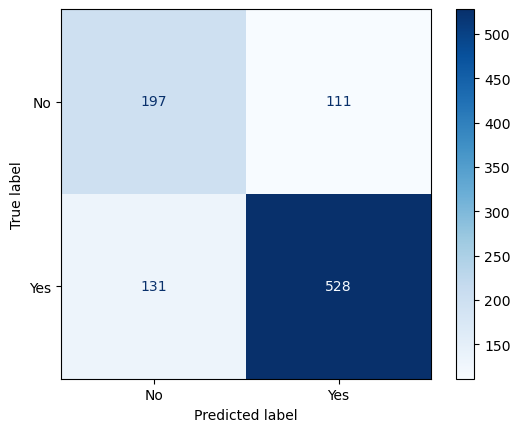

,DT
Accuracy,0.75
Precision,0.83
Recall,0.80
F1score,0.81


In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score,\
                            recall_score,f1_score, \
                            confusion_matrix,ConfusionMatrixDisplay,\
                            roc_curve,auc
import matplotlib.pyplot as plt
#--------------------- Read the data ------------------------------------
df=pd.read_csv('Preprocessed_data.csv')
X=df.drop('Customer Status',axis=1)
y= df['Customer Status']

#----------------------- train test split ---------------------------------
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1234)

#------------------------ Model development ----------------------------------
DT=DecisionTreeClassifier()
DT.fit(X_train,y_train)

#----------------------- Model prediction ----------------------------------
dt_pred=DT.predict(X_test)

#--------------------------- Model evaluation ---------------------------------
cmt_tree=confusion_matrix(y_test,dt_pred)
ConfusionMatrixDisplay(cmt_tree,display_labels=['No','Yes']).plot(cmap='Blues')
plt.show()

acc_dt=round(accuracy_score(y_test,dt_pred),2)
acc_pr=round(precision_score(y_test,dt_pred),2)
acc_rc=round(recall_score(y_test,dt_pred),2)
acc_f1=round(f1_score(y_test,dt_pred),2)

l1=acc_dt,acc_pr,acc_rc,acc_f1

pd.DataFrame(l1,columns=['DT'],index=['Accuracy','Precision','Recall','F1score'])

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# take the screenshot and post in whatapp group

**ROC-AUC**

- X-axis: 1-specificity  (FPR)

- Y-axis: Sensitivity    (TPR)

- If you recall we did by using probability

- we need postive class probability 

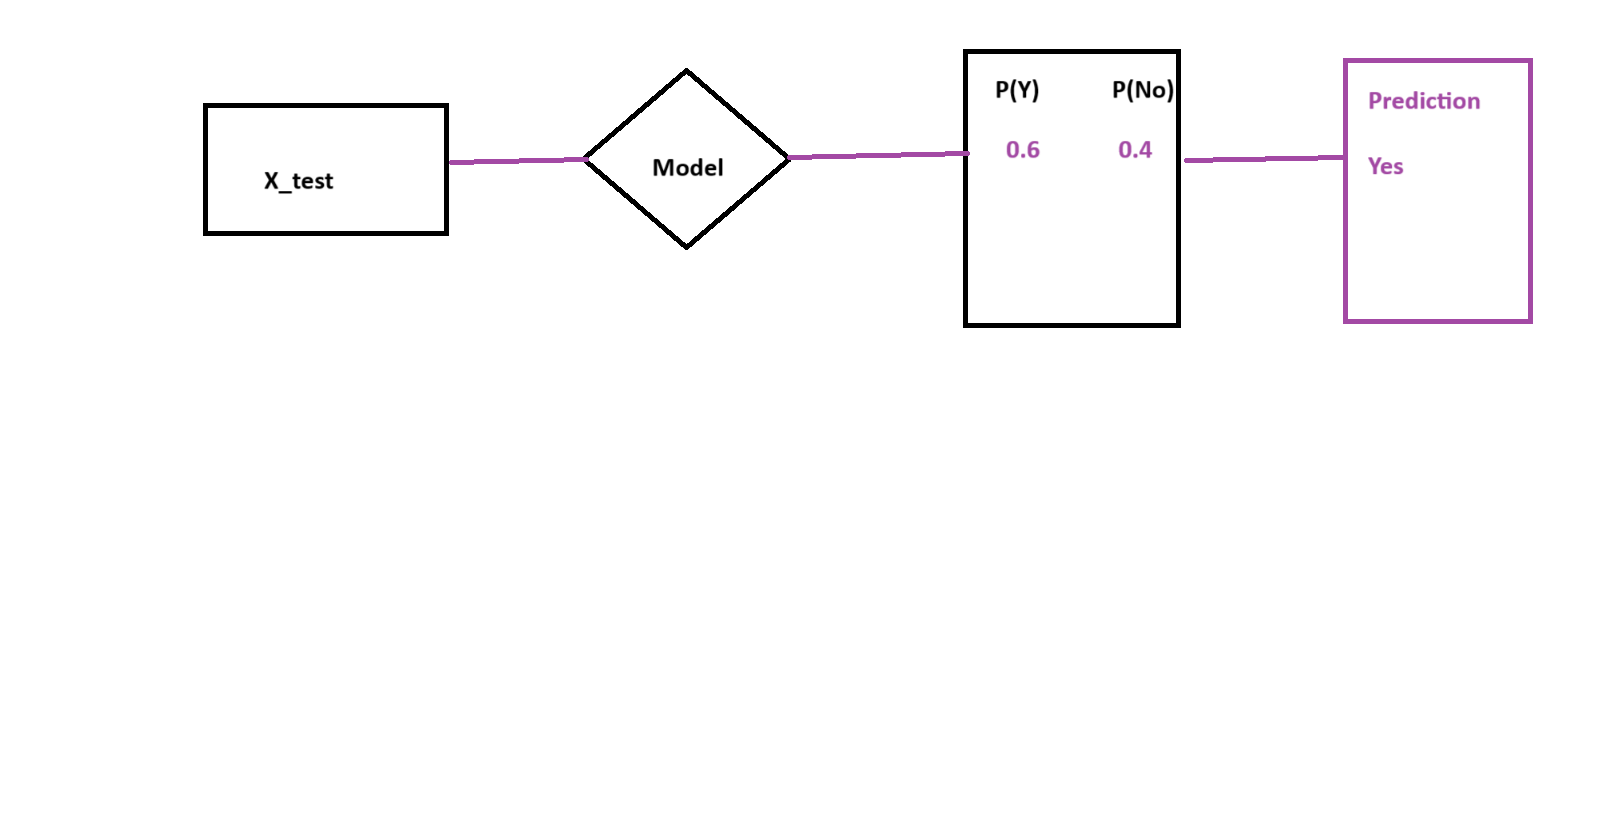

**predict_prob**

In [74]:
dt_prob=DT.predict_proba(X_test)
dt_prob_df=pd.DataFrame(dt_prob,columns=['p(n)','p(y)'])
con=dt_prob_df['p(n)']==0.0
#np.where(<con>,<True>,<False>)
final_d=np.where(con,1,0)
dt_prob_df['Final_pred']=final_d
y_pred=DT.predict(X_test)
dt_prob_df['Y_pred']=y_pred
dt_prob_df

,p(n),p(y),Final_pred,Y_pred
0,0.0,1.0,1,1
1,0.0,1.0,1,1
2,1.0,0.0,0,0
3,0.0,1.0,1,1
4,0.0,1.0,1,1
...,...,...,...,...
962,0.0,1.0,1,1
963,0.0,1.0,1,1
964,1.0,0.0,0,0
965,0.0,1.0,1,1


**we need to extract only postive probability samples**

In [83]:
dt_prob=DT.predict_proba(X_test)
class_1_prob=dt_prob[:,1]
class_1_prob

array([1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 0., 0., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0., 0.,
       0., 1., 1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 1., 1., 1., 1.,
       0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 0.,
       0., 0., 1., 1., 0., 1., 1., 1., 0., 0., 1., 1., 1., 0., 1., 0., 0.,
       0., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 0., 0., 1., 1., 1., 1.,
       0., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 0., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0.,
       1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 1., 1., 0., 1., 0.,
       0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 0., 1., 0., 1., 0.,
       1., 1., 0., 0., 0.

auc_score: 0.7204121750783359


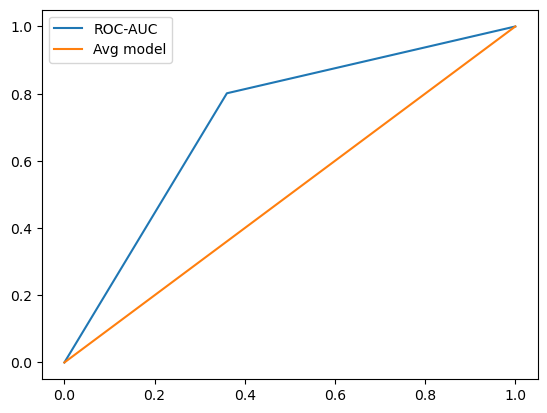

In [101]:
fpr, tpr, thresholds=roc_curve(y_test,class_1_prob)
plt.plot(fpr,tpr,label='ROC-AUC')
plt.plot([0,1],[0,1],label='Avg model')
plt.legend()
auc_score=auc(fpr,tpr)
print('auc_score:',auc_score)